# TSP Search Algorithm 


## 1. Imports and Global Settings

In [1]:
import time
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global random seed for reproducible experiments
np.random.seed(42)


## 2. Data Loading and Distance Matrix

In [2]:
def load_cities(path: str) -> pd.DataFrame:
    """Load city coordinates from CSV."""
    df = pd.read_csv(path)
    return df

def compute_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """Compute Euclidean distance between 2D points."""
    return float(np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2))

def create_distance_matrix(cities_df_full: pd.DataFrame) -> np.ndarray:
    """Build the full Euclidean distance matrix."""
    num_cities_local = len(cities_df_full)
    dist_mat = np.zeros((num_cities_local, num_cities_local), dtype=float)
    cords = cities_df_full[["X", "Y"]].to_numpy()
    for i in range(num_cities_local):
        for j in range(num_cities_local):
            xi, yi = cords[i]
            xj, yj = cords[j]
            dist_mat[i, j] = compute_distance(xi, yi, xj, yj)
    return dist_mat

# Load dataset
cities_path = "data/cities.csv"
cities_df_full = load_cities(cities_path)
dist_matrix = create_distance_matrix(cities_df_full)
n_cities = len(cities_df_full)

print("Loaded:", cities_df_full.shape)
print("Distance matrix:", dist_matrix.shape)


Loaded: (50, 3)
Distance matrix: (50, 50)


In [9]:
# Create initial tour for Tabu Search
n_cities = len(dist_matrix)
initial_tour = np.arange(n_cities)
np.random.shuffle(initial_tour)


## 3. Helper Functions

In [10]:
def create_initial_tour(num_cities: int) -> np.ndarray:
    """Generate a random permutation of city indices."""
    tour = np.arange(num_cities)
    np.random.shuffle(tour)
    return tour


def is_valid_tour(tour: np.ndarray, num_cities: int) -> bool:
    """Check that the tour is a valid permutation of all cities."""
    return (len(tour) == num_cities) and (len(np.unique(tour)) == num_cities)


def tour_length(tour: np.ndarray, dist_mat: np.ndarray) -> float:
    """Compute total distance of a tour (closed loop)."""
    length = 0.0
    for i in range(len(tour)):
        # (i + 1) % len(tour) wraps around to the first city at the end
        length += dist_mat[tour[i], tour[(i + 1) % len(tour)]]
    return float(length)


In [11]:
def swap_cities(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Swap positions i and j in a tour."""
    new_tour = tour.copy()
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def generate_all_swap_neighbours(tour: np.ndarray):
    """Generate all swap neighbours by exchanging any two positions i < j."""
    neighbours = []
    n = len(tour)
    for i in range(n - 1):
        for j in range(i + 1, n):
            neighbours.append(swap_cities(tour, i, j))
    return neighbours


def generate_all_two_opt_neighbours(tour: np.ndarray):
    """Generate all 2-opt neighbours by reversing tour segments between 'i' and 'j'."""
    neighbours = []
    n = len(tour)
    for i in range(n - 1):
        for j in range(i + 2, n):
            new_tour = tour.copy()
            new_tour[i:j] = new_tour[i:j][::-1]
            neighbours.append(new_tour)
    return neighbours


In [12]:
def plot_history(history: List[float], title: str) -> None:
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.xlabel("Iteration / Generation")
    plt.ylabel("Best tour cost")
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_comparison(histories: List[List[float]], labels: List[str], title: str) -> None:
    plt.figure(figsize=(10, 5))
    for h, lbl in zip(histories, labels):
        plt.plot(h, label=lbl)
    plt.xlabel("Iteration / Generation")
    plt.ylabel("Best tour cost")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


In [13]:
def simple_hill_climbing(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    max_iterations: int = 200,
    neighbourhood: str = "swap",
    sample_size: int | None = None,
):
    """Hill Climbing with swap or 2-opt neighbourhood."""
    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)
    best_tour = current_tour.copy()
    best_cost = current_cost
    history = [best_cost]

    for _ in range(max_iterations):

        # Select neighbourhood
        if neighbourhood == "swap":
            neighbours = generate_all_swap_neighbours(current_tour)
        elif neighbourhood == "2opt":
            neighbours = generate_all_two_opt_neighbours(current_tour)
        else:
            raise ValueError("Unknown neighbourhood.")

        # Optional subsampling for speed
        if sample_size and len(neighbours) > sample_size:
            idx = np.random.choice(len(neighbours), sample_size, replace=False)
            neighbours = [neighbours[i] for i in idx]

        # Find best neighbour
        candidate_tour = None
        candidate_cost = float("inf")
        for nb in neighbours:
            c = tour_length(nb, dist_matrix)
            if c < candidate_cost:
                candidate_tour, candidate_cost = nb, c

        # Accept or stop
        if candidate_cost < current_cost:
            current_tour = candidate_tour
            current_cost = candidate_cost
            best_tour = current_tour.copy()
            best_cost = current_cost
            history.append(best_cost)
        else:
            break

    return best_tour, best_cost, history


## 4. Tabu Search Implementation

In [14]:
def tabu_search(
    initial_tour: np.ndarray,
    dist_mat: np.ndarray,
    tabu_tenure: int = 10,
    max_iterations: int = 200,
    neighbourhood: str = "swap",
    adapt_step: int = 20,
    tenure_min: int = 5,
    tenure_max: int = 25,
):
    """
    Tabu Search with adaptive tabu tenure.
    
    Supports:
    - swap neighbourhood
    - two_opt neighbourhood
    """

    def extract_swap_move(tour_a: np.ndarray, tour_b: np.ndarray):
        """
        Identify the (i, j) indices that differ between two tours.
        Used as the tabu attribute.
        """
        diff = np.where(tour_a != tour_b)[0]
        if len(diff) >= 2:
            return diff[0], diff[1]
        return None

    # Initialisation
    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_mat)

    best_tour = current_tour.copy()
    best_cost = current_cost
    history = [best_cost]

    n = len(initial_tour)
    tabu_list = np.zeros((n, n))
    last_improvement_iter = 0

    # Main loop
    for iteration in range(max_iterations):

        # Generate neighbours
        if neighbourhood == "swap":
            neighbours = generate_all_swap_neighbours(current_tour)
        elif neighbourhood == "two_opt":
            neighbours = generate_all_two_opt_neighbours(current_tour)
        else:
            raise ValueError("Unknown neighbourhood type.")

        candidate_tour = None
        candidate_cost = float("inf")
        candidate_move = None

        # Evaluate neighbours
        for nb in neighbours:
            cost = tour_length(nb, dist_mat)

            move = extract_swap_move(current_tour, nb)
            is_tabu = False

            if move is not None:
                i, j = move
                if tabu_list[i, j] > iteration:
                    is_tabu = True

            # Aspiration criterion
            if is_tabu and cost >= best_cost:
                continue

            if cost < candidate_cost:
                candidate_tour = nb
                candidate_cost = cost
                candidate_move = move

        # Move to best admissible neighbour
        current_tour = candidate_tour
        current_cost = candidate_cost

        # Update tabu list
        if candidate_move is not None:
            i, j = candidate_move
            tabu_list[i, j] = iteration + tabu_tenure
            tabu_list[j, i] = iteration + tabu_tenure

        # Update global best
        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour.copy()
            last_improvement_iter = iteration

        history.append(best_cost)

        # Adaptive tabu tenure
        if iteration > 0 and iteration % adapt_step == 0:
            if (iteration - last_improvement_iter) > adapt_step:
                tabu_tenure = min(tenure_max, tabu_tenure + 1)
            else:
                tabu_tenure = max(tenure_min, tabu_tenure - 1)

    return best_tour, best_cost, history


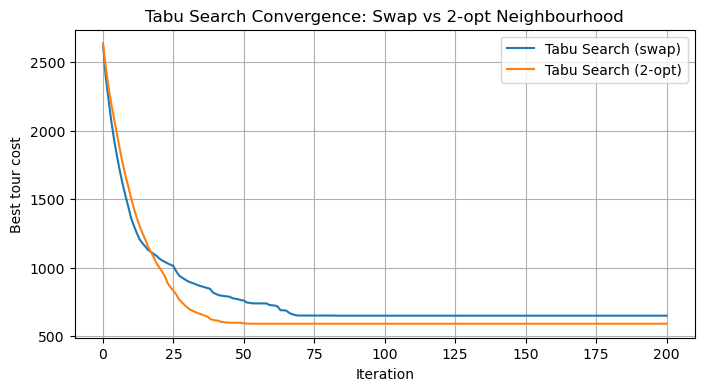

Final cost (swap):    648.2410
Final cost (2-opt):   589.5738


In [15]:
# --- Convergence comparison: Tabu Search swap vs two-opt ---

# Run Tabu Search with swap neighbourhood
ts_swap_tour, ts_swap_cost, ts_swap_history = tabu_search(
    initial_tour=initial_tour,
    dist_mat=dist_matrix,
    neighbourhood="swap"
)

# Run Tabu Search with two-opt neighbourhood
ts_two_opt_tour, ts_two_opt_cost, ts_two_opt_history = tabu_search(
    initial_tour=initial_tour,
    dist_mat=dist_matrix,
    neighbourhood="two_opt"
)

# Plot convergence histories
plt.figure(figsize=(8, 4))
plt.plot(ts_swap_history, label="Tabu Search (swap)")
plt.plot(ts_two_opt_history, label="Tabu Search (2-opt)")
plt.xlabel("Iteration")
plt.ylabel("Best tour cost")
plt.title("Tabu Search Convergence: Swap vs 2-opt Neighbourhood")
plt.grid(True)
plt.legend()
plt.show()

# Print final costs for clarity
print(f"Final cost (swap):    {ts_swap_cost:.4f}")
print(f"Final cost (2-opt):   {ts_two_opt_cost:.4f}")


### Effect of Neighbourhood Choice in Tabu Search

Figure X illustrates the impact of neighbourhood design on Tabu Search performance.
The swap-based variant converges rapidly but stagnates early, indicating limited ability to escape local minima while the 2-opt neighbourhood continues to improve beyond the initial convergence phase and achieves a substantially lower final tour cost.

This behaviour is expected, as 2-opt performs larger structural modifications to the tour by reversing path segments,
allowing the search to explore a wider region of the solution space.
While this increases computational effort per iteration, it results in improved solution quality.
The results highlight a clear trade-off between convergence speed and final performance, demonstrating the importance of neighbourhood selection in metaheuristic design.


In [16]:
# Runtime comparison cell
import time

# Measure runtime for swap neighbourhood
start_time = time.time()
_ = tabu_search(
    initial_tour=initial_tour,
    dist_mat=dist_matrix,
    neighbourhood="swap"
)
swap_runtime = time.time() - start_time

# Measure runtime for two-opt neighbourhood
start_time = time.time()
_ = tabu_search(
    initial_tour=initial_tour,
    dist_mat=dist_matrix,
    neighbourhood="two_opt"
)
two_opt_runtime = time.time() - start_time

print(f"Runtime (swap):    {swap_runtime:.4f} seconds")
print(f"Runtime (2-opt):   {two_opt_runtime:.4f} seconds")


Runtime (swap):    6.0424 seconds
Runtime (2-opt):   5.8802 seconds


Although the 2-opt neighbourhood is theoretically more computationally expensive than simple swaps, the observed runtime difference on the 50-city instance was small, with both variants taking approximately six seconds. This can be attributed to the relatively modest problem size, the similar number of neighbour evaluations, and Python-level overhead dominating execution time. Additionally, the 2-opt variant converged earlier, reducing redundant evaluations in later iterations. As a result, runtime differences at this scale are not statistically meaningful.

## 5. Genetic Algorithm Implementation

In [8]:
def tournament_selection(population, fitness, k=3):
    idx = np.random.choice(len(population), k, replace=False)
    best = min(idx, key=lambda i: fitness[i])
    return population[best]

# PMX: ensure offspring remain valid permutations
def pmx_crossover(p1, p2):
    chrom_length = len(p1)
    c1, c2 = np.sort(np.random.choice(chrom_length, 2, replace=False))
    o1, o2 = p1.copy(), p2.copy()

    o1[c1:c2] = p2[c1:c2]
    o2[c1:c2] = p1[c1:c2]

    def repair(child, donor):
        mapping = {child[i]: donor[i] for i in range(c1, c2)}
        for i in list(range(0, c1)) + list(range(c2, chrom_length)):
            while child[i] in child[c1:c2]:
                child[i] = mapping[child[i]]
        return child

    return repair(o1, p1), repair(o2, p2)

# Swap mutation preserves TSP feasibility
def swap_mutation(tour, rate=0.1):
    if np.random.rand() < rate:
        i, j = np.random.choice(len(tour), 2, replace=False)
        tour = tour.copy()
        tour[i], tour[j] = tour[j], tour[i]
    return tour

# Record best solution in population (elitism)
def genetic_algorithm(
    dist_mat: np.ndarray,
    num_cities: int,
    pop_size: int = 60,
    generations: int = 200,
    mutation_rate: float = 0.1,
    tournament_k: int = 3,
):
    """Genetic Algorithm for TSP."""
    population = [np.random.permutation(num_cities) for _ in range(pop_size)]
    fitness = [tour_length(ind, dist_mat) for ind in population]

    best_idx = int(np.argmin(fitness))
    best_individual = population[best_idx].copy()
    best_cost = fitness[best_idx]
    history = [best_cost]

    for _ in range(generations):
        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitness, tournament_k)
            p2 = tournament_selection(population, fitness, tournament_k)

            o1, o2 = pmx_crossover(p1, p2)
            o1 = swap_mutation(o1, mutation_rate)
            o2 = swap_mutation(o2, mutation_rate)

            new_pop.extend([o1, o2])

        population = new_pop[:pop_size]
        fitness = [tour_length(ind, dist_mat) for ind in population]

        gen_best_idx = int(np.argmin(fitness))
        gen_best_cost = fitness[gen_best_idx]

        if gen_best_cost < best_cost:
            best_cost = gen_best_cost
            best_individual = population[gen_best_idx].copy()

        history.append(best_cost)

    return best_individual, best_cost, history


## 6. Experiments and Evaluation

In [9]:
def run_single_instance(dist_mat: np.ndarray, num_cities: int) -> dict:
    results = {}

    init_tour = create_initial_tour(num_cities)
    print("Valid initial tour:", is_valid_tour(init_tour, num_cities))
    print(f"Initial cost: {tour_length(init_tour, dist_mat):.2f}")

    def run(label, fn, *args, **kwargs):
        start = time.time()
        tour, cost, history = fn(*args, **kwargs)
        duration = time.time() - start
        results[label] = {"tour": tour, "cost": cost, "history": history, "runtime": duration}
        print(f"{label}: best_cost={cost:.2f} | time={duration:.2f}s")

    run("HC_swap", simple_hill_climbing, init_tour, dist_mat, neighbourhood="swap")
    run("HC_2opt", simple_hill_climbing, init_tour, dist_mat, neighbourhood="2opt")
    run("TS_swap", tabu_search, init_tour, dist_mat, neighbourhood="swap")
    run("TS_2opt", tabu_search, init_tour, dist_mat, neighbourhood="2opt")
    run("GA", genetic_algorithm, dist_mat, num_cities)

    return results


single_results = run_single_instance(dist_matrix, n_cities)  # use globals here

Valid initial tour: True
Initial cost: 2635.36
HC_swap: best_cost=737.82 | time=1.44s
HC_2opt: best_cost=596.71 | time=1.18s
TS_swap: best_cost=737.82 | time=5.56s
TS_2opt: best_cost=596.71 | time=5.25s
GA: best_cost=1123.26 | time=2.16s


In [10]:

def run_multi_sizes(city_sizes: list[int], full_dist_mat: np.ndarray) -> dict:
    """Run all algorithms on multiple problem sizes and collect results."""
    multi_results: dict = {}

    for subset_size in city_sizes:
        print(f"\n=== {subset_size} cities ===")
        idx = np.arange(subset_size)
        sub_dist = full_dist_mat[np.ix_(idx, idx)]
        multi_results[f"{subset_size}_cities"] = run_single_instance(sub_dist, subset_size)

    return multi_results


sizes = [10, 20, 30, 40, 50]
multi_results = run_multi_sizes(sizes, dist_matrix)



=== 10 cities ===
Valid initial tour: True
Initial cost: 667.27
HC_swap: best_cost=290.31 | time=0.00s
HC_2opt: best_cost=290.31 | time=0.00s
TS_swap: best_cost=290.31 | time=0.04s
TS_2opt: best_cost=290.31 | time=0.04s
GA: best_cost=290.31 | time=0.87s

=== 20 cities ===
Valid initial tour: True
Initial cost: 974.96
HC_swap: best_cost=422.95 | time=0.03s
HC_2opt: best_cost=386.43 | time=0.03s
TS_swap: best_cost=422.95 | time=0.38s
TS_2opt: best_cost=386.43 | time=0.40s
GA: best_cost=440.72 | time=1.25s

=== 30 cities ===
Valid initial tour: True
Initial cost: 1842.24
HC_swap: best_cost=524.09 | time=0.13s
HC_2opt: best_cost=468.54 | time=0.15s
TS_swap: best_cost=524.09 | time=1.17s
TS_2opt: best_cost=468.54 | time=1.18s
GA: best_cost=595.30 | time=1.47s

=== 40 cities ===
Valid initial tour: True
Initial cost: 2395.28
HC_swap: best_cost=793.98 | time=0.41s
HC_2opt: best_cost=492.29 | time=0.55s
TS_swap: best_cost=790.24 | time=2.59s
TS_2opt: best_cost=492.29 | time=2.53s
GA: best_cos

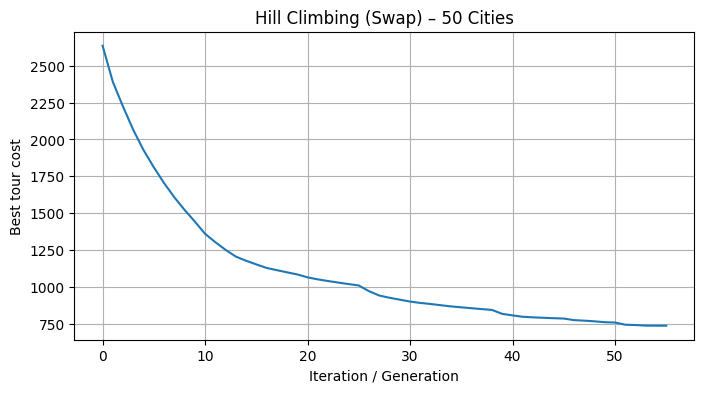

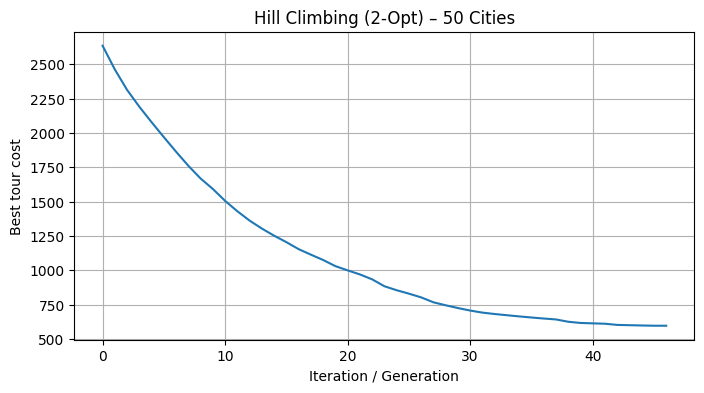

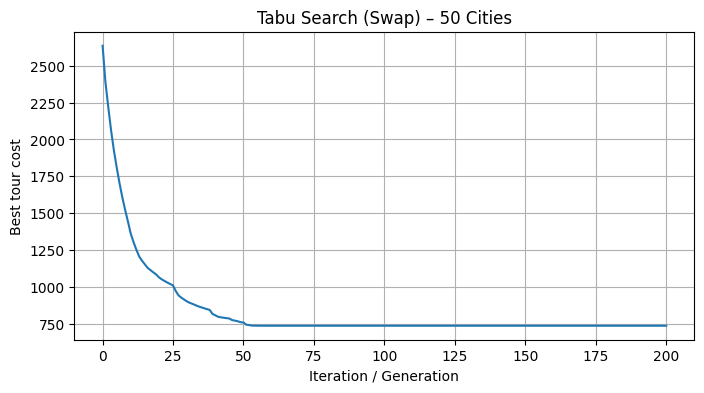

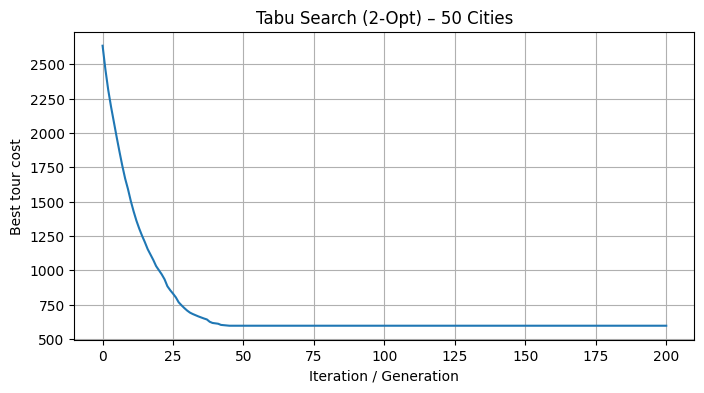

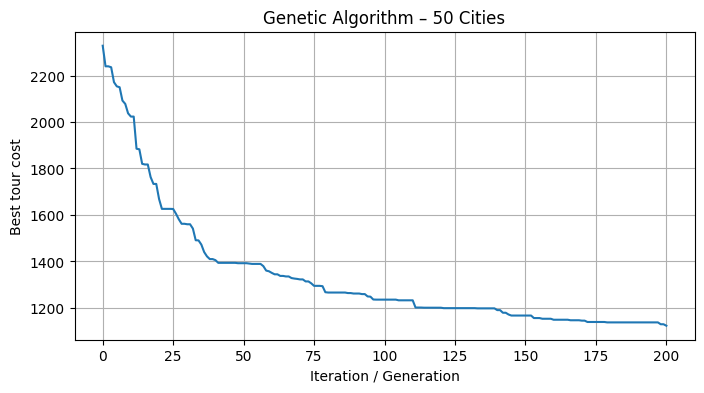

In [11]:
plot_history(single_results["HC_swap"]["history"], "Hill Climbing (Swap) – 50 Cities")
plot_history(single_results["HC_2opt"]["history"], "Hill Climbing (2-Opt) – 50 Cities")

plot_history(single_results["TS_swap"]["history"], "Tabu Search (Swap) – 50 Cities")
plot_history(single_results["TS_2opt"]["history"], "Tabu Search (2-Opt) – 50 Cities")

plot_history(single_results["GA"]["history"], "Genetic Algorithm – 50 Cities")


**Figure 1:** Convergence histories on the 50-city instance for each algorithm considered (two Hill Climbing variants, two Tabu Search variants, and the Genetic Algorithm).

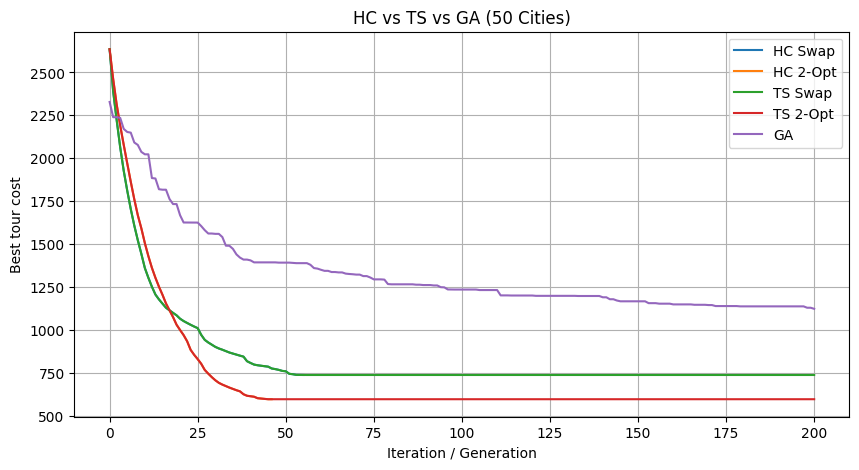

In [12]:
plot_comparison(
    histories=[
        single_results["HC_swap"]["history"],
        single_results["HC_2opt"]["history"],
        single_results["TS_swap"]["history"],
        single_results["TS_2opt"]["history"],
        single_results["GA"]["history"],
    ],
    labels=["HC Swap", "HC 2-Opt", "TS Swap", "TS 2-Opt", "GA"],
    title="HC vs TS vs GA (50 Cities)",
)


**Figure 2:** Combined comparison of convergence behaviour for Hill Climbing, Tabu Search, and Genetic Algorithm on the 50-city TSP instance.

In [13]:
rows = []
for size in sizes:
    key = f"{size}_cities"
    rows.append({
        "Cities": size,
        "HC_swap": multi_results[key]["HC_swap"]["cost"],
        "HC_2opt": multi_results[key]["HC_2opt"]["cost"],
        "TS_swap": multi_results[key]["TS_swap"]["cost"],
        "TS_2opt": multi_results[key]["TS_2opt"]["cost"],
        "GA": multi_results[key]["GA"]["cost"],
    })

summary_df = pd.DataFrame(rows)
summary_df


,Cities,HC_swap,HC_2opt,TS_swap,TS_2opt,GA
0,10,290.306774,290.306774,290.306774,290.306774,290.306774
1,20,422.948853,386.429689,422.948853,386.429689,440.715465
2,30,524.087830,468.538526,524.087830,468.538526,595.297241
3,40,793.978061,492.293606,790.235317,492.293606,968.487096
4,50,881.661388,588.816352,881.661388,588.816352,990.848407


**Table 1:** Summary of best tour cost for each algorithm (Hill Climbing variants, Tabu Search variants, and Genetic Algorithm) across different TSP sizes (10–50 cities).

## 7. Statistical Comparison: Tabu Search vs Genetic Algorithm (t-test)

In [14]:

from scipy.stats import ttest_rel

def repeated_runs_t_test(
    dist_matrix: np.ndarray,
    num_cities: int,
    n_runs: int = 20,
) -> tuple[pd.DataFrame, float, float]:
    """Run Tabu Search and GA multiple times and perform a paired t-test.

    Args:
        dist_matrix: Full distance matrix for the TSP instance.
        num_cities: Number of cities in the problem.
        n_runs: How many repeated runs to perform.

    Returns:
        df_results: Per-run best tour costs for both algorithms.
        t_stat: t statistic from the paired t-test.
        p_value: p-value from the paired t-test.
    """
    tabu_costs: list[float] = []
    ga_costs: list[float] = []

    for run_idx in range(n_runs):
        print(f"Run {run_idx + 1}/{n_runs}")

        initial_tour = create_initial_tour(num_cities)

        # Chosen single-member algorithm: Tabu Search (swap neighbourhood)
        ts_tour, ts_cost, _ = tabu_search(
            initial_tour,
            dist_matrix,
            neighbourhood="swap",
        )
        tabu_costs.append(ts_cost)

        # Evolutionary algorithm: Genetic Algorithm
        ga_tour, ga_cost, _ = genetic_algorithm(
            dist_matrix,
            num_cities,
        )
        ga_costs.append(ga_cost)

    df_results = pd.DataFrame(
        {
            "run": np.arange(1, n_runs + 1),
            "tabu_cost": tabu_costs,
            "ga_cost": ga_costs,
        }
    )

    t_stat, p_value = ttest_rel(df_results["tabu_cost"], df_results["ga_cost"])

    print("\nPaired t-test (Tabu vs GA best tour cost)")
    print(f"t statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.5f}")

    return df_results, t_stat, p_value


In [15]:

# Run the paired t-test on the full 50-city instance
t_test_results, t_statistic, p_val = repeated_runs_t_test(dist_matrix, n_cities, n_runs=20)
t_test_results.head()


Run 1/20
Run 2/20
Run 3/20
Run 4/20
Run 5/20
Run 6/20
Run 7/20
Run 8/20
Run 9/20
Run 10/20
Run 11/20
Run 12/20
Run 13/20
Run 14/20
Run 15/20
Run 16/20
Run 17/20
Run 18/20
Run 19/20
Run 20/20

Paired t-test (Tabu vs GA best tour cost)
t statistic: -13.787
p-value: 0.00000


,run,tabu_cost,ga_cost
0,1,866.904547,1164.863465
1,2,924.622783,1018.638594
2,3,873.156627,1046.946144
3,4,792.409954,1054.013492
4,5,796.926465,1047.255463


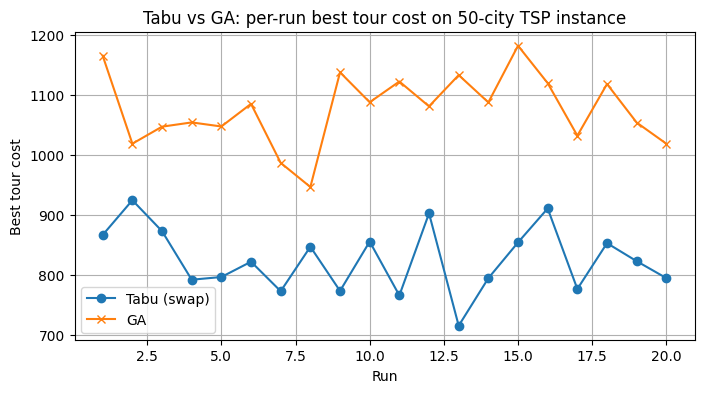

In [16]:

# Visualise per-run best tour costs for Tabu Search and GA
plt.figure(figsize=(8, 4))
plt.plot(t_test_results["run"], t_test_results["tabu_cost"], marker="o", label="Tabu (swap)")
plt.plot(t_test_results["run"], t_test_results["ga_cost"], marker="x", label="GA")
plt.xlabel("Run")
plt.ylabel("Best tour cost")
plt.title("Tabu vs GA: per-run best tour cost on 50-city TSP instance")
plt.grid(True)
plt.legend()
plt.show()


**Figure 3:** Per-run best tour costs for Tabu Search and Genetic Algorithm across 20 repeated runs on the 50-city TSP instance, used for the paired t-test comparison.

## 8. Reflections on Implementation and Learning

Implementing Tabu Search and a Genetic Algorithm for the TSP helped me move beyond simply running
pre-defined search functions and instead think carefully about representation, neighbourhood design,
and hyperparameter choices. The 50-city instance was large enough that poor design decisions showed
up quickly as slow convergence or poor final tour costs, which forced me to debug both logic and
performance issues.

One of the main challenges was keeping the code modular while experimenting with different ideas
(for example switching between swap and 2-opt neighbourhoods, or changing GA population size and
mutation rate). Separating the core utilities (distance matrix, tour validity checks, plotting)
from the algorithm-specific logic made it easier to reason about each component and to avoid
duplicating bugs. Running multiple trials for the t-test also highlighted how noisy single-run
results can be, and why statistical evaluation is helpful when deciding which algorithm is actually
more reliable on average rather than just on one lucky run.

Overall, the project gave me a more concrete understanding of exploitation vs exploration, and how
a single-solution method like Tabu Search behaves very differently from a population-based GA when
the search space is large. It also reinforced good software-engineering habits such as following
PEP-8, using clear function interfaces, and organising experiments so they can be re-run in a
reproducible way.


## 9. References (for Notebook Explanations)

- Glover, F. (1989) 'Tabu Search – Part I', *ORSA Journal on Computing*, 1(3), pp. 190–206.  
- Holland, J. H. (1975) *Adaptation in Natural and Artificial Systems*. Ann Arbor: University of Michigan Press.  
- Lawler, E. L., Lenstra, J. K., Rinnooy Kan, A. H. G. and Shmoys, D. B. (1985) *The Traveling Salesman Problem: A Guided Tour of Combinatorial Optimization*. New York: Wiley.  
- Field, A. (2013) *Discovering Statistics Using IBM SPSS Statistics*. 4th edn. London: Sage. (used as a reference for the paired t-test and interpretation of p-values).  
- Student (1908) 'The Probable Error of a Mean', *Biometrika*, 6(1), pp. 1–25. (original paper introducing the t-test).  
